In [1]:
# Install libraries
# !pip install openpyxl
# !pip install numpy 
# !pip install pandas 
# !pip install matplotlib
# !pip install seaborn
# !pip install statsmodels
# !pip install pmdarima
# Import libraries 
# Standard libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm


# Diagnostics
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Model Selection
import pmdarima as pm

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Open dataframes

file = "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx"
# Monthly
df = pd.read_excel(
    file,
    sheet_name=3
)

# Macroeconomic Factors
macro = pd.read_excel(
    file,
    sheet_name=4
)

# Prices of various oil equities and indexes
prices = pd.read_excel(
    file,
    sheet_name=5
)

# Verify if the data loaded in correctly 
# d.head()
# w.head()
# m.head()
# macro.head()
# prices.head()

# Sort time-series so that it is in order 
df = df.sort_values("Date")
macro = macro.sort_values("Date")
prices = prices.sort_values("Date")

# Checking the datatypes to ensure that date has been time-series set
# m.dtypes

# Ensure Date is datetime and set as index
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")


df.head()

,CL1,CL2,Brent,CRKS321C Index,Baltic Dry Index,Daily Production,Inventories,Rig Count,Commercial Long,Commercial Short,Total Open Interest
Date,,,,,,,,,,,
1994-12-30,17.76,17.71,16.50,2.387,1965,6675,904519,791,288400,287502,575902
1995-01-31,18.39,18.24,16.80,1.575,1973,6526,898253,731,287720,293477,581197
1995-02-28,18.49,18.35,16.87,1.870,2038,6546,896939,696,275392,287982,563374
1995-03-31,19.17,18.95,17.50,2.474,2209,6380,912742,648,260845,271270,532115
1995-04-28,20.38,20.05,19.06,4.656,2347,6539,910037,680,268845,279756,548601


# Preparing the Data for Forecasting
## Selecting our dependent variable
We choose to make our dependent variable the CL2-CL1 spread as it is economically the most valuable for understanding the oil market. We hope that our results can help us to further understand the seasonality structure that is found in the oil market. Using spreads helps us to capture seasonlity, which isn't captured in prices (as it comes up as white noise), for factors such as, geopolitical risk, macro shocks, financial flows and USD movements (FX market).

We deicde to use monthly prices to construct our spread variables in order to ensure consistency across the information set. While a weekly frequency would be preferable given the trading horizon, the majority of economically informative explanatory variables in the dataset are observed at a monthly frequency. Aligning prices to this frequency avoids temporal misalignment, reducing the risk of introducing spurious dynamics into the model. Monthly prices also mitigates the impact of high-frequency noise, which is particularly common in oil markets due to their inherent volatility. Therefore, we exclude utilising daily prices as their short-term fluctuations are unlikely to provide stable predictive content for medium-horizon forecasts.

In [3]:
"""
We construct a monthly futures spread as the difference between the second-month (CL2) and first-month (CL1) 
WTI crude oil futures contracts, defined as CL2 - CL1.

Note: 
- CL1 > CL2 = Backwardation [supply shortage]
- CL1 < CL2 = Contango [excess supply]
"""

df["spread"] = df["CL2"] - df["CL1"]

df.head()

,CL1,CL2,Brent,CRKS321C Index,Baltic Dry Index,Daily Production,Inventories,Rig Count,Commercial Long,Commercial Short,Total Open Interest,spread
Date,,,,,,,,,,,,
1994-12-30,17.76,17.71,16.50,2.387,1965,6675,904519,791,288400,287502,575902,-0.05
1995-01-31,18.39,18.24,16.80,1.575,1973,6526,898253,731,287720,293477,581197,-0.15
1995-02-28,18.49,18.35,16.87,1.870,2038,6546,896939,696,275392,287982,563374,-0.14
1995-03-31,19.17,18.95,17.50,2.474,2209,6380,912742,648,260845,271270,532115,-0.22
1995-04-28,20.38,20.05,19.06,4.656,2347,6539,910037,680,268845,279756,548601,-0.33


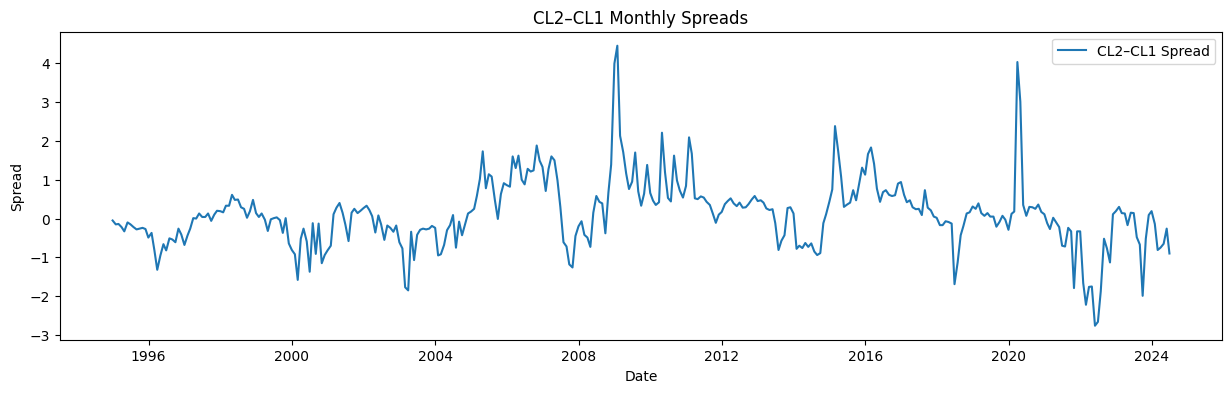

In [ ]:
# Define target variable
y = df['spread']

plt.figure(figsize=(15, 4))
plt.plot(df.index, y, label="CL2–CL1 Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.title("CL2–CL1 Monthly Spreads")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Diagnostics and Explanatory Variable Selection
 ## Splitting the data into training and testing set

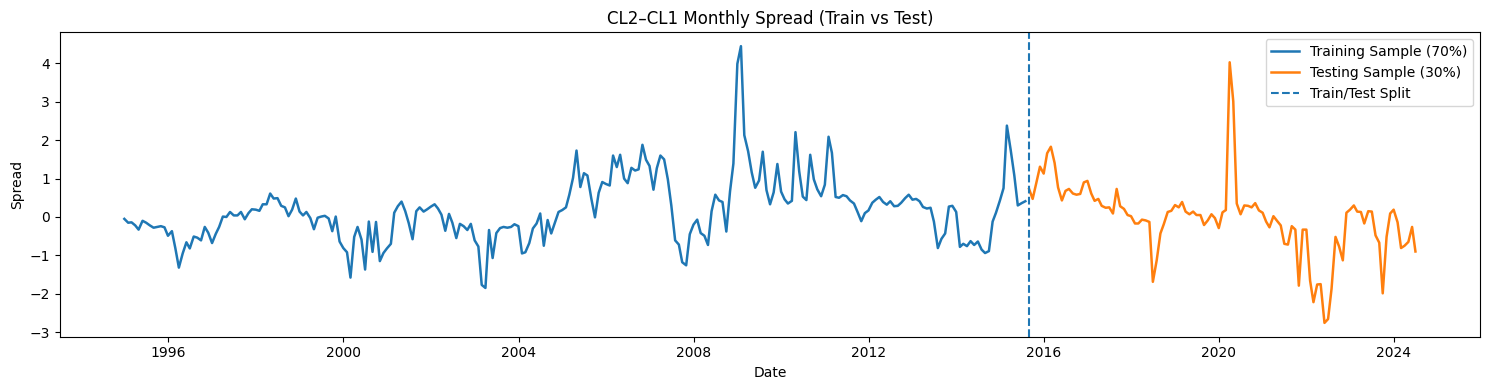

In [ ]:
"""
Before we run any diagnostics and select any explanatory variables, we must start by splitting our data into a training 
and testing test. We should do this before running any diagonistics to prevent overfitting our data onto our testing 
sample and leading to unreliable out-of-sample results. 

We deice to utilise a 70:30 train:test split after observing the time-series plot above. The reason being that 
the training sample spans multiple market regimes, including periods of elevated volatility and structural stress, 
allowing the model to learn oil spread dynamics under diverse conditions. The test sample corresponds to a relatively 
stable regime, providing a rigourous evaluation of the model’s ability to generalise out of sample.
"""

# Ensure time order
if "Date" in df.columns:
    df = df.sort_values("Date").reset_index(drop=True)
else:
    df = df.sort_index()

# Create split - 70% training, 30% testing
split = int(len(df) * 0.7)

df_train = df.iloc[:split].copy()
df_test  = df.iloc[split:].copy()

y_train = df_train["spread"]
y_test  = df_test["spread"]

plt.figure(figsize=(15, 4))

x_train = df_train["Date"] if "Date" in df_train.columns else df_train.index
x_test  = df_test["Date"]  if "Date" in df_test.columns  else df_test.index

plt.plot(x_train, y_train, label="Training Sample (70%)", linewidth=1.8)
plt.plot(x_test,  y_test,  label="Testing Sample (30%)", linewidth=1.8)

plt.axvline(x=x_test[0], linestyle="--", linewidth=1.5, label="Train/Test Split")

plt.xlabel("Date")
plt.ylabel("Spread")
plt.title("CL2–CL1 Monthly Spread (Train vs Test)")
plt.legend()
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


# Diagnostic Tests (Stationarity)

In [6]:
# Test for Stationarity (ADF and KPSS Test)

# Create a function for ADF and KPSS Test 
def stationarity_sum(series, name=""):
    series = series.dropna()

    adf = adfuller(series)
    kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression="c", nlags="auto")

    print(f"\n{name}")
    print("-" * len(name))
    print(f"ADF p-value  : {adf[1]:.4f}")
    print(f"KPSS p-value : {kpss_p:.4f}")


stationarity_sum(df_train["spread"], "CL2-CL1 Spread")


CL2-CL1 Spread
--------------
ADF p-value  : 0.0000
KPSS p-value : 0.0177


In [7]:
# Difference the time-series
spread_diff = df_train["spread"].diff().dropna()

stationarity_sum(spread_diff, "CL2-CL1 Spread (Differenced)")


CL2-CL1 Spread (Differenced)
----------------------------
ADF p-value  : 0.0000
KPSS p-value : 0.1000


# Plotting ACF and PACF

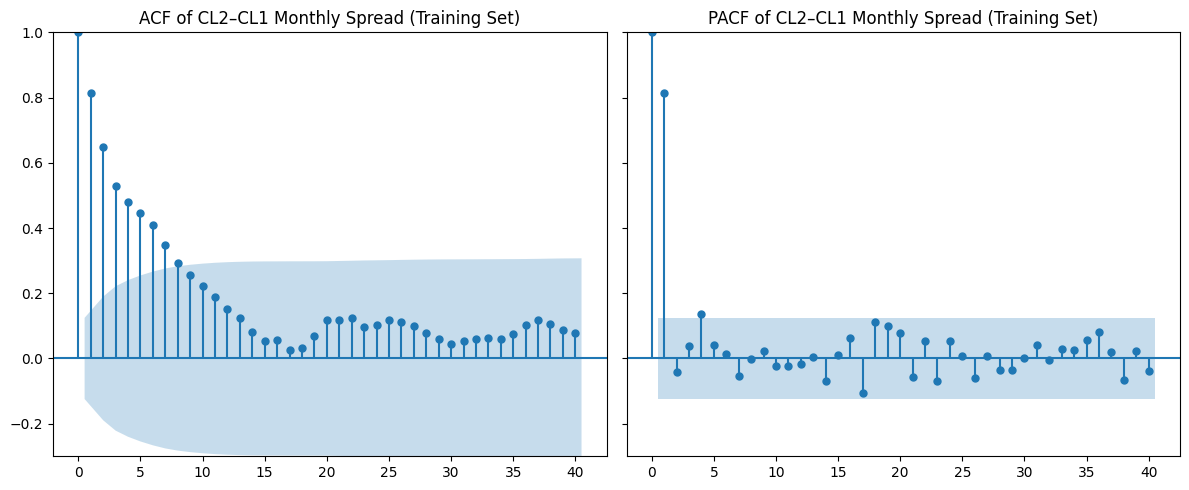

In [ ]:
# ACF and PACF Plots

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ACF
plot_acf(
    df_train["spread"],
    lags=40,
    ax=axes[0]
)
axes[0].set_title("ACF of CL2–CL1 Monthly Spread (Training Set)")
axes[0].set_ylim(-0.3, 1)

# PACF
plot_pacf(
    df_train["spread"],
    lags=40,
    ax=axes[1]
)
axes[1].set_title("PACF of CL2–CL1 Monthly Spread (Training Set)")
axes[1].set_ylim(-0.3, 1)

plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

# Auto-Arima Optimal Lag Choice

In [9]:
# Define maximum lags
max_lags = 10

# Function to return model order AND IC values
def auto_arima_lag(series, max_lags, criterion):
    model = pm.auto_arima(
        series,
        start_p=0, start_q=0,
        max_p=max_lags, max_q=max_lags,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        information_criterion=criterion
    )
    
    return {
        "order": model.order,
        "AIC": model.aic(),
        "BIC": model.bic(),
        "HQIC": model.hqic()
    }

# Run for each criterion
results = {
    'AIC': auto_arima_lag(df_train['spread'], max_lags, 'aic'),
    'BIC': auto_arima_lag(df_train['spread'], max_lags, 'bic'),
    'HQIC': auto_arima_lag(df_train['spread'], max_lags, 'hqic')
}

# Print results cleanly
for criterion, output in results.items():
    print(f"\nOptimised by {criterion}")
    print(f"Selected order: {output['order']}")
    print(f"AIC: {output['AIC']:.4f}")
    print(f"BIC: {output['BIC']:.4f}")
    print(f"HQIC: {output['HQIC']:.4f}")


Optimised by AIC
Selected order: (0, 1, 0)
AIC: 365.2760
BIC: 368.7854
HQIC: 366.6890

Optimised by BIC
Selected order: (0, 1, 0)
AIC: 365.2760
BIC: 368.7854
HQIC: 366.6890

Optimised by HQIC
Selected order: (0, 1, 0)
AIC: 365.2760
BIC: 368.7854
HQIC: 366.6890


We find that using just levels-form spread, that we are basically running a random walk. This is not invalid, but it is a weak baseline. Therefore, for something more sophisticated and accurate for forecasting, we will proceed to use the log form form of the spreads, i.e. ln(CL2/CL1)

log_spread_t = $\log\!\left(\frac{CL2_t}{CL1_t}\right)$



In [10]:
df["ln_spread"] = np.log(df["CL2"]) - np.log(df["CL1"])

# Then split
split = int(len(df) * 0.7)
df_train = df.iloc[:split]
df_test  = df.iloc[split:]

In [11]:
stationarity_sum(df_train["ln_spread"], "log(CL2-CL1) Spread")

# Stationary at 99% Confidence Interval in levels form


log(CL2-CL1) Spread
-------------------
ADF p-value  : 0.0000
KPSS p-value : 0.0230


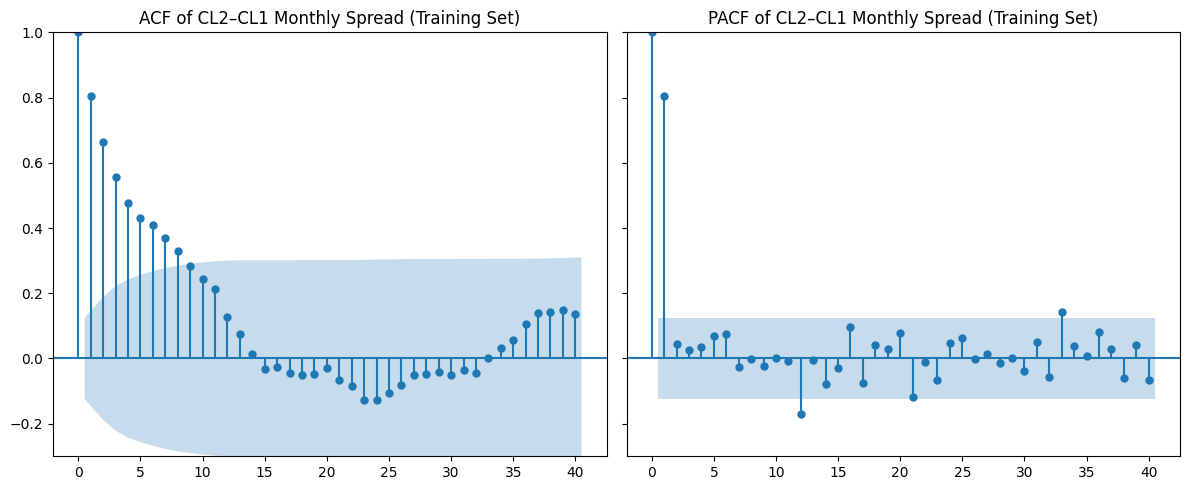

In [ ]:
# ACF and PACF Plots
# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ACF
plot_acf(
    df_train["ln_spread"],
    lags=40,
    ax=axes[0]
)
axes[0].set_title("ACF of CL2–CL1 Monthly Spread (Training Set)")
axes[0].set_ylim(-0.3, 1)

# PACF
plot_pacf(
    df_train["ln_spread"],
    lags=40,
    ax=axes[1]
)
axes[1].set_title("PACF of CL2–CL1 Monthly Spread (Training Set)")
axes[1].set_ylim(-0.3, 1)

plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# Define maximum lags
max_lags = 10

# Function to return model order AND IC values
def auto_arima_lag(series, max_lags, criterion):
    model = pm.auto_arima(
        series,
        start_p=0, start_q=0,
        max_p=max_lags, max_q=max_lags,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        information_criterion=criterion
    )
    
    return {
        "order": model.order,
        "AIC": model.aic(),
        "BIC": model.bic(),
        "HQIC": model.hqic()
    }

# Run for each criterion
results = {
    'AIC': auto_arima_lag(df_train['ln_spread'], max_lags, 'aic'),
    'BIC': auto_arima_lag(df_train['ln_spread'], max_lags, 'bic'),
    'HQIC': auto_arima_lag(df_train['ln_spread'], max_lags, 'hqic')
}

# Print results cleanly
for criterion, output in results.items():
    print(f"\nOptimised by {criterion}")
    print(f"Selected order: {output['order']}")
    print(f"AIC: {output['AIC']:.4f}")
    print(f"BIC: {output['BIC']:.4f}")
    print(f"HQIC: {output['HQIC']:.4f}")

best_aic_key = min(results, key=lambda k: results[k]["AIC"])
best_order = results[best_aic_key]["order"]



Optimised by AIC
Selected order: (1, 1, 1)
AIC: -1491.4294
BIC: -1480.9013
HQIC: -1487.1907

Optimised by BIC
Selected order: (1, 1, 1)
AIC: -1491.4294
BIC: -1480.9013
HQIC: -1487.1907

Optimised by HQIC
Selected order: (1, 1, 1)
AIC: -1491.4294
BIC: -1480.9013
HQIC: -1487.1907


# Fitting ARIMA(0,1,0)

In [14]:
# Using optimal lags from AIC

model_arima = ARIMA(y_train, order=best_order)   
results_arima = model_arima.fit()

print(results_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                 spread   No. Observations:                  248
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -170.518
Date:                Tue, 17 Feb 2026   AIC                            347.037
Time:                        05:09:42   BIC                            357.565
Sample:                    12-30-1994   HQIC                           351.275
                         - 07-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7826      0.035     22.386      0.000       0.714       0.851
ma.L1         -0.9767      0.017    -57.832      0.000      -1.010      -0.944
sigma2         0.2318      0.011     20.747      0.0

# Analysing Residuals

Residual diagnostics are conducted to assess the adequacy of the selected ARIMA specification. At the 5% significance level, the Ljung–Box test fails to reject the null of no residual autocorrelation, indicating that the model successfully captures the linear dependence structure in the data. However, the ARCH LM test rejects the null of homoskedasticity, providing evidence of remaining conditional heteroskedasticity in the residuals. In addition, the Jarque–Bera test strongly rejects the null hypothesis of normality, suggesting that the residual distribution exhibits non-Gaussian features such as excess kurtosis. These findings are common in financial time series and do not invalidate the model for forecasting purposes, but they motivate caution in statistical inference and suggest that volatility-robust methods or alternative error specifications may be appropriate.

,Test,p-value
0,Ljung-Box (lag 10),6.582265e-01
1,ARCH LM (lag 10),2.204267e-02
2,Jarque-Bera,4.997068e-81


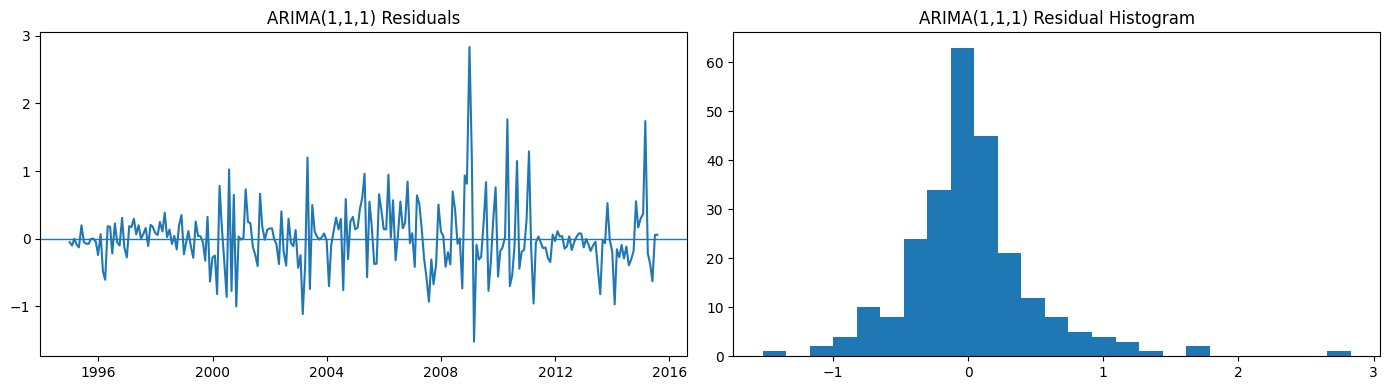

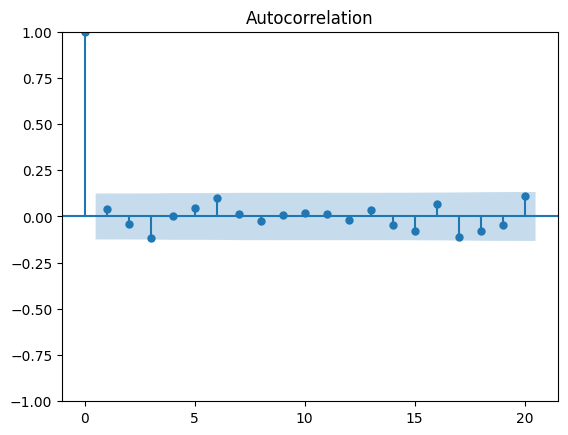

In [ ]:
# Residuals
residuals_arima = results_arima.resid.copy()
residuals_arima.index = df_train.index[:len(residuals_arima)].values

# Ljung-Box (autocorrelation)
lb = acorr_ljungbox(residuals_arima, lags=[10], return_df=True)

# ARCH (conditional heteroskedasticity)
arch_stat, arch_p, _, _ = het_arch(residuals_arima, nlags=10)

# Jarque-Bera (normality)
jb_stat, jb_p, skew, kurt = jarque_bera(residuals_arima)

diag_tbl = pd.DataFrame({
    "Test": ["Ljung-Box (lag 10)", "ARCH LM (lag 10)", "Jarque-Bera"],
    "p-value":   [float(lb["lb_pvalue"].iloc[0]), float(arch_p), float(jb_p)]
})

display(diag_tbl)

# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residual time series
axes[0].plot(residuals_arima.index, residuals_arima.values)
axes[0].axhline(0, linewidth=1)
axes[0].set_title("ARIMA(1,1,1) Residuals")

# Residual histogram
axes[1].hist(residuals_arima.values, bins=25)
axes[1].set_title("ARIMA(1,1,1) Residual Histogram")

plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

# Residual ACF
plot_acf(residuals_arima, lags=20);

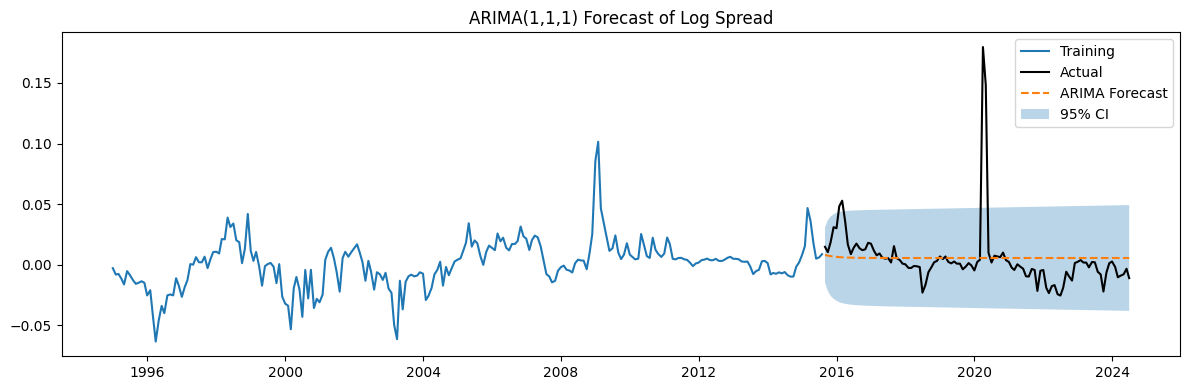

In [ ]:
# Split
split = int(len(df) * 0.7)
df_train = df.iloc[:split]
df_test  = df.iloc[split:]

# Fit + forecast
order = (1, 1, 1)
res = ARIMA(df_train["ln_spread"], order=order).fit()

fc = res.get_forecast(steps=len(df_test))
forecast_mean = fc.predicted_mean
forecast_ci = fc.conf_int(alpha=0.05)

forecast_df = pd.DataFrame({
    "forecast": forecast_mean,
    "lower": forecast_ci.iloc[:, 0],
    "upper": forecast_ci.iloc[:, 1]
}, index=df_test.index)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(df_train.index, df_train["ln_spread"], label="Training")
plt.plot(df_test.index, df_test["ln_spread"], label="Actual", color="black")
plt.plot(forecast_df.index, forecast_df["forecast"], label="ARIMA Forecast", linestyle="--")
plt.fill_between(forecast_df.index, forecast_df["lower"], forecast_df["upper"], alpha=0.3, label="95% CI")
plt.title("ARIMA(1,1,1) Forecast of Log Spread")
plt.legend()
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


In [17]:
# Metrics

y_train = df_train["ln_spread"]
y_test  = df_test["ln_spread"]
y_pred  = forecast_df["forecast"]

# Benchmarks on test set
# Last observation benchmark: y_hat_t = y_{t-1}
bench_last = pd.concat([y_train.iloc[-1:], y_test.iloc[:-1]])
bench_last.index = y_test.index

# Train mean benchmark
bench_mean = pd.Series(float(y_train.mean()), index=y_test.index)

# Metric functions
def mae(y_true, y_hat):
    return float(np.mean(np.abs(y_true - y_hat)))

def rmse(y_true, y_hat):
    return float(np.sqrt(np.mean((y_true - y_hat) ** 2)))

def hitrate(y_true, y_hat, y_prev):
    # Directional accuracy relative to previous actual value
    actual_dir = np.sign(y_true - y_prev)
    pred_dir   = np.sign(y_hat - y_prev)
    return float(np.mean(actual_dir.values == pred_dir.values))

def oos_r2(y_true, y_hat, y_bench):
    sse_model = float(np.sum((y_true - y_hat) ** 2))
    sse_bench = float(np.sum((y_true - y_bench) ** 2))
    return np.nan if sse_bench == 0 else 1.0 - (sse_model / sse_bench)

# Assemble metrics table
metrics = pd.DataFrame({
    "Hitrate": [hitrate(y_test, y_pred, bench_last)],
    "MAE": [mae(y_test, y_pred)],
    "RMSE": [rmse(y_test, y_pred)],
    "OOS_R2_vs_LastObs": [oos_r2(y_test, y_pred, bench_last)],
    "OOS_R2_vs_TrainMean": [oos_r2(y_test, y_pred, bench_mean)]
}, index=[f"ARIMA{order}"])

display(metrics)

,Hitrate,MAE,RMSE,OOS_R2_vs_LastObs,OOS_R2_vs_TrainMean
"ARIMA(1, 1, 1)",0.523364,0.012786,0.025603,-0.251952,0.025412


# Variable Pre-Processing for OLS and ARIMAX Model

In [18]:
# Build y_train, y_test from df_train/df_test
y_train = (
    pd.Series(
        df_train["ln_spread"].to_numpy(),
        index=pd.to_datetime(df_train.index),
        name="ln_spread",
    )
    .sort_index()
)

y_test = (
    pd.Series(
        df_test["ln_spread"].to_numpy(),
        index=pd.to_datetime(df_test.index),
        name="ln_spread",
    )
    .sort_index()
)

In [19]:
# Build monthly exog matrix aligned to y (avoid look-ahead)
def build_exog(macro: pd.DataFrame, prices: pd.DataFrame, exog_lag: int = 1) -> pd.DataFrame:
    macro_i = macro.copy()
    prices_i = prices.copy()

    macro_i["Date"] = pd.to_datetime(macro_i["Date"])
    prices_i["Date"] = pd.to_datetime(prices_i["Date"])

    macro_i = macro_i.sort_values("Date").set_index("Date")
    prices_i = prices_i.sort_values("Date").set_index("Date")

    exog = pd.concat([macro_i, prices_i], axis=1)

    # Drop duplicated columns if any
    exog = exog.loc[:, ~exog.columns.duplicated()]

    # Keep only numeric exogenous columns (avoid corr() surprises)
    exog = exog.select_dtypes(include=[np.number])

    # Lag to ensure you only use information known before trading date
    exog = exog.shift(exog_lag)

    return exog

In [20]:
EXOG_LAG = 1  # set to 0 only if contemporaneous availability is assumed
exog_all = build_exog(macro, prices, exog_lag=EXOG_LAG)

# Align exog to train/test indices and drop missing rows (ARIMAX cannot handle NaNs)
X_train = exog_all.reindex(y_train.index)
X_test = exog_all.reindex(y_test.index)

train_df = pd.concat([y_train, X_train], axis=1).dropna()
test_df = pd.concat([y_test, X_test], axis=1).dropna()

y_train = train_df["ln_spread"]
X_train = train_df.drop(columns=["ln_spread"])

y_test = test_df["ln_spread"]
X_test = test_df.drop(columns=["ln_spread"])

In [21]:
# Drop highly correlated features (pairwise correlation filter) 
def drop_high_corr_features(X: pd.DataFrame, threshold: float = 0.85) -> pd.DataFrame:
    """
    Greedy filter: for any pair with |corr| > threshold, drop one variable.
    The choice is based on which variable has higher average absolute correlation with others.
    Safe against 'underlying array is read-only' by working on a writable numpy copy.
    """
    # Only numeric columns for correlation
    X_num = X.select_dtypes(include=[np.number]).copy()

    # Drop constant columns (corr becomes NaN)
    nunique = X_num.nunique(dropna=False)
    X_num = X_num.loc[:, nunique > 1].copy()

    # If nothing/one column left, return original (minus any constants)
    if X_num.shape[1] <= 1:
        keep_cols = X_num.columns.tolist()
        return X.reindex(columns=keep_cols)

    Xc = X_num.copy()
    to_drop = set()

    while Xc.shape[1] > 1:
        corr_df = Xc.corr().abs()

        # Work on a writable numpy array for diagonal-zeroing
        corr = corr_df.to_numpy(copy=True)
        np.fill_diagonal(corr, 0.0)

        max_corr = np.nanmax(corr)
        if np.isnan(max_corr) or max_corr <= threshold:
            break

        # Find pair with max correlation
        i, j = np.argwhere(corr == max_corr)[0]
        col_i = corr_df.index[i]
        col_j = corr_df.columns[j]

        # Average absolute correlation (using the diagonal-zeroed corr matrix)
        mean_abs = np.nanmean(corr, axis=0)
        mean_i = mean_abs[i]
        mean_j = mean_abs[j]

        drop_col = col_i if mean_i >= mean_j else col_j
        to_drop.add(drop_col)

        Xc = Xc.drop(columns=[drop_col])

    kept = [c for c in X_num.columns if c not in to_drop]
    return X.reindex(columns=kept)

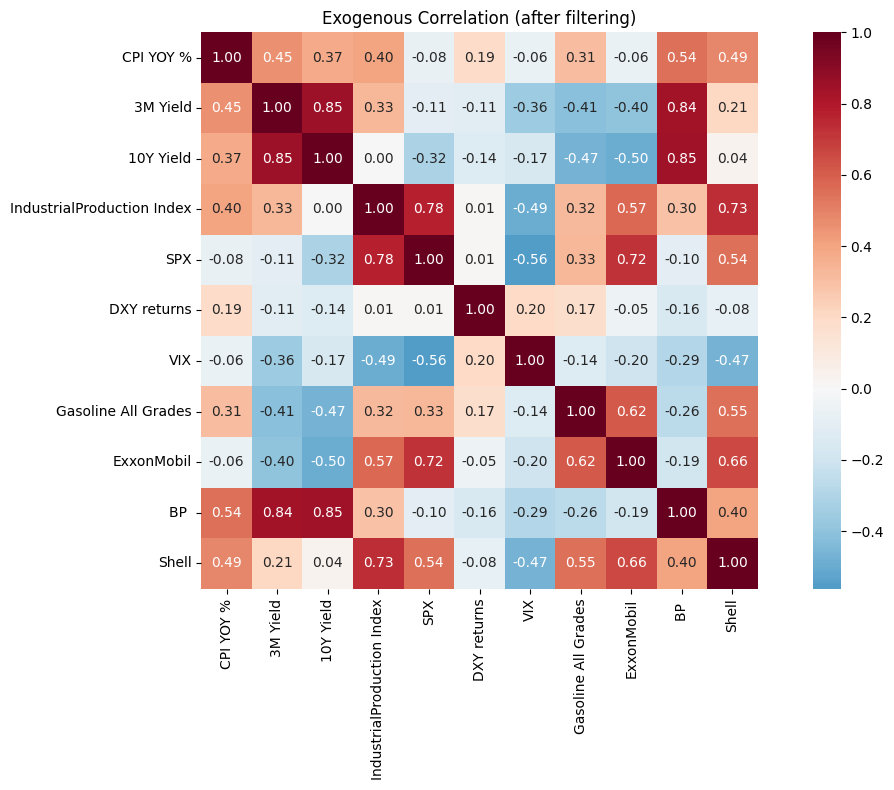

In [22]:
CORR_THRESH = 0.85
X_train_f = drop_high_corr_features(X_train, threshold=CORR_THRESH)

X_test_f = X_test.reindex(columns=X_train_f.columns)

plt.figure(figsize=(12, 8))
corr_show = X_train_f.corr(numeric_only=True)
sns.heatmap(corr_show, 
            annot=True, 
            fmt=".2f", 
            cmap="RdBu_r", 
            center=0, 
            square=True)
plt.title(f"Exogenous Correlation (after filtering)")
plt.tight_layout()
plt.show()

In [23]:
# VIF Filter to mitigate multicollinearty from occurring
def compute_vif(X: pd.DataFrame) -> pd.Series:
    X_ = X.copy()
    X_ = X_.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="any")
    if X_.shape[1] == 0:
        return pd.Series(dtype=float)
    # add constant implicitly by centering (VIF doesn't require explicit const, but helps numerically)
    Xv = X_.values
    vifs = []
    for k in range(X_.shape[1]):
        vifs.append(variance_inflation_factor(Xv, k))
    return pd.Series(vifs, index=X_.columns, name="VIF")

def drop_high_vif(X: pd.DataFrame, vif_threshold: float = 10.0) -> pd.DataFrame:
    """
    Iteratively drop the variable with the highest VIF until all VIFs <= threshold.
    """
    Xc = X.copy()
    while Xc.shape[1] > 1:
        v = compute_vif(Xc)
        if v.empty or np.nanmax(v.values) <= vif_threshold:
            break
        drop_col = v.idxmax()
        Xc = Xc.drop(columns=[drop_col])
    return Xc

max_vif = 10.0
X_train_f = drop_high_vif(X_train_f, vif_threshold=max_vif)
X_test_f = X_test_f.reindex(columns=X_train_f.columns)

# Print final exog set
print("Final exogenous variables used in ARIMAX:")
print(list(X_train_f.columns))

Final exogenous variables used in ARIMAX:
['CPI YOY %', '3M Yield', 'SPX', 'DXY returns', 'VIX']


In [24]:
# ============================================================
# Fix the "no frequency information" warning
# (do this once after y_train/y_test and X_train_f/X_test_f exist)
# Choose ONE: "M" (month-end) or "BM" (business month-end)


FREQ = "ME"   # try "BM" if your dates are business month-end

# Force frequency on y (and align to X)
y_train = y_train.asfreq(FREQ)
y_test  = y_test.asfreq(FREQ)

X_train_f = X_train_f.asfreq(FREQ)
X_test_f  = X_test_f.asfreq(FREQ)

# Drop any rows that became missing due to asfreq alignment (safety)
train_df = pd.concat([y_train, X_train_f], axis=1).dropna()
test_df  = pd.concat([y_test,  X_test_f],  axis=1).dropna()

y_train = train_df["ln_spread"]
X_train_f = train_df.drop(columns=["ln_spread"])

y_test = test_df["ln_spread"]
X_test_f = test_df.drop(columns=["ln_spread"])

print("Post-freq shapes:", y_train.shape, X_train_f.shape, y_test.shape, X_test_f.shape)

Post-freq shapes: (54,) (54, 5) (49,) (49, 5)


In [25]:
y_train.index = y_train.index.to_period("M").to_timestamp("M")
y_test.index  = y_test.index.to_period("M").to_timestamp("M")

# ARIMAX model

In [26]:
def arimax_grid_search_statespace(
    y: pd.Series,
    X: pd.DataFrame,
    p_max: int = 4,
    d_values=(0, 1),
    q_max: int = 4,
    trend: str = "n",
    skip_nonconverged: bool = True,
    enforce_stationarity: bool = False,
    enforce_invertibility: bool = False,
):
    # --- align + clean ---
    df = pd.concat([y.rename("y"), X], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
    y2 = df["y"]
    X2 = df.drop(columns=["y"])

    # Drop constant cols (can break estimation)
    X2 = X2.loc[:, X2.nunique(dropna=True) > 1].copy()
    X2 = X2.loc[:, X2.std() > 1e-12].copy()

    if X2.shape[1] == 0:
        raise ValueError("X has no usable columns after cleaning (constants/NaNs removed).")

    rows, fails = [], []

    for d in d_values:
        for p in range(p_max + 1):
            for q in range(q_max + 1):
                if (p, d, q) == (0, 0, 0):
                    continue
                try:
                    res = ARIMA(
                        y2,
                        order=(p, d, q),
                        exog=X2,
                        trend=trend,
                        enforce_stationarity=enforce_stationarity,
                        enforce_invertibility=enforce_invertibility,
                    ).fit(method="statespace")

                    converged = bool(getattr(res, "mle_retvals", {}).get("converged", True))
                    if skip_nonconverged and (not converged):
                        continue

                    rows.append({
                        "order": (p, d, q),
                        "p": p, "d": d, "q": q,
                        "AIC": float(res.aic),
                        "BIC": float(res.bic),
                        "HQIC": float(res.hqic),
                        "converged": converged
                    })

                except Exception as e:
                    fails.append({"order": (p, d, q), "error": str(e)[:250]})

    grid = pd.DataFrame(rows).sort_values(["AIC", "BIC", "HQIC"]).reset_index(drop=True)
    fail_df = pd.DataFrame(fails)

    print("Successful fits kept:", len(grid))
    print("Failed fits:", len(fail_df))

    if grid.empty:
        # show common reasons
        if not fail_df.empty:
            print("\nTop failure reasons:")
            print(fail_df["error"].value_counts().head(10))
        return {"AIC": None, "BIC": None, "HQIC": None}, grid, fail_df

    best = {
        "AIC": tuple(grid.loc[grid["AIC"].idxmin(), "order"]),
        "BIC": tuple(grid.loc[grid["BIC"].idxmin(), "order"]),
        "HQIC": tuple(grid.loc[grid["HQIC"].idxmin(), "order"]),
    }

    print("Best by AIC :", best["AIC"])
    print("Best by BIC :", best["BIC"])
    print("Best by HQIC:", best["HQIC"])

    return best, grid, fail_df


In [27]:
best, grid, fails = arimax_grid_search_statespace(
    y=y_train,
    X=X_train_f,
    p_max=4,
    d_values=(0, 1),
    q_max=4,
    trend="n",
    skip_nonconverged=True
)

display(grid.head(15))
print("Selected ARIMAX order (AIC):", best["AIC"])
print("Selected ARIMAX order (BIC):", best["BIC"])
print("Selected ARIMAX order (HQIC):", best["HQIC"])

arimax_order_1 = (0,1,0)
arimax_order_2 = (2,1,0)

Successful fits kept: 7
Failed fits: 0
Best by AIC : (0, 1, 0)
Best by BIC : (0, 1, 0)
Best by HQIC: (0, 1, 0)


,order,p,d,q,AIC,BIC,HQIC,converged
0,"(0, 1, 0)",0,1,0,-355.889498,-344.182035,-351.401133,True
1,"(2, 1, 0)",2,1,0,-350.269081,-334.814476,-344.363420,True
2,"(2, 1, 2)",2,1,2,-348.311968,-329.191738,-341.030876,True
3,"(0, 1, 2)",0,1,2,-345.884179,-330.587994,-340.059304,True
4,"(2, 1, 1)",2,1,1,-338.581726,-321.195295,-331.937856,True
5,"(3, 1, 3)",3,1,3,-337.720788,-315.018945,-329.107741,True
6,"(4, 1, 3)",4,1,3,-335.306016,-310.712352,-325.975214,True


Selected ARIMAX order (AIC): (0, 1, 0)
Selected ARIMAX order (BIC): (0, 1, 0)
Selected ARIMAX order (HQIC): (0, 1, 0)


Although information criteria marginally favour an ARIMAX(0,1,0) specification, this model implies a random-walk process in the log spread and therefore offers limited dynamic structure for forecasting. To address this, an ARIMAX(2,1,0) model is also estimated, introducing minimal autoregressive dynamics while remaining parsimonious. This alternative specification allows for short-run dependence in the differenced spread and facilitates a comparison based on residual diagnostics and out-of-sample forecast performance rather than information criteria alone.

In [28]:
# Fit ARIMAX(0,1,0) Model 
model_arimax_010 = ARIMA(y_train, order=arimax_order_1, exog=X_train_f)
results_arimax_010 = model_arimax_010.fit()

print(results_arimax_010.summary())

                               SARIMAX Results                                
Dep. Variable:              ln_spread   No. Observations:                   54
Model:                 ARIMA(0, 1, 0)   Log Likelihood                 186.874
Date:                Tue, 17 Feb 2026   AIC                           -361.748
Time:                        05:09:44   BIC                           -349.927
Sample:                             0   HQIC                          -357.202
                                 - 54                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
CPI YOY %      -0.0002      0.001     -0.213      0.831      -0.002       0.002
3M Yield        0.0012      0.003      0.368      0.713      -0.005       0.007
SPX         -3.876e-05   2.11e-05     -1.835    

In [29]:
# Fit ARIMAX(2,1,0) Model 
model_arimax_210 = ARIMA(y_train, order=arimax_order_2, exog=X_train_f)
results_arimax_210 = model_arimax_210.fit()

print(results_arimax_210.summary())

                               SARIMAX Results                                
Dep. Variable:              ln_spread   No. Observations:                   54
Model:                 ARIMA(2, 1, 0)   Log Likelihood                 189.825
Date:                Tue, 17 Feb 2026   AIC                           -363.651
Time:                        05:09:44   BIC                           -347.889
Sample:                             0   HQIC                          -357.590
                                 - 54                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
CPI YOY %      -0.0005      0.001     -0.542      0.588      -0.002       0.001
3M Yield        0.0012      0.003      0.412      0.681      -0.004       0.007
SPX         -2.834e-05   1.43e-05     -1.977    

In [30]:
# Diagnostics 

# Diagnostics for one fitted ARIMAX result function
def arimax_diagnostics(results, model_name: str, lb_lag: int = 10, arch_lag: int = 10) -> pd.Series:
    resid = results.resid
    # Some ARIMA results return numpy arrays; make Series for safety
    if not isinstance(resid, pd.Series):
        resid = pd.Series(resid)
    resid = resid.dropna()

    # Ljung-Box
    lb = acorr_ljungbox(resid, lags=[lb_lag], return_df=True)

    # ARCH LM
    arch_stat, arch_p, _, _ = het_arch(resid, nlags=arch_lag)

    # Jarque-Bera
    jb_stat, jb_p, skew, kurt = jarque_bera(resid)

    return pd.Series({
        "Model": model_name,
        "Order": str(getattr(results, "model", None).order if hasattr(results, "model") else "N/A"),
        "AIC": float(results.aic),
        "BIC": float(results.bic),
        "HQIC": float(results.hqic),
        "LjungBox_stat": float(lb["lb_stat"].iloc[0]),
        "LjungBox_p": float(lb["lb_pvalue"].iloc[0]),
        "ARCH_stat": float(arch_stat),
        "ARCH_p": float(arch_p),
        "JB_stat": float(jb_stat),
        "JB_p": float(jb_p),
        "Skew": float(skew),
        "Kurtosis": float(kurt),
        "n_obs": int(len(resid))
    })


# Compare ARIMAX(0,1,0) vs ARIMAX(2,1,0) in one table
diag_010 = arimax_diagnostics(results_arimax_010, "ARIMAX(0,1,0)")
diag_210 = arimax_diagnostics(results_arimax_210, "ARIMAX(2,1,0)")

compare_tbl = pd.DataFrame([diag_010, diag_210]).set_index("Model")

cols_order = [
    "Order", "AIC", "BIC", "HQIC",
    "LjungBox_p",
    "ARCH_p",
    "JB_p",
]
compare_tbl = compare_tbl[cols_order]

display(compare_tbl)

,Order,AIC,BIC,HQIC,LjungBox_p,ARCH_p,JB_p
Model,,,,,,,
"ARIMAX(0,1,0)","(0, 1, 0)",-361.748355,-349.926603,-357.202279,0.844006,0.884031,4.148608e-74
"ARIMAX(2,1,0)","(2, 1, 0)",-363.650974,-347.888638,-357.589540,0.958555,0.734396,6.682648e-27


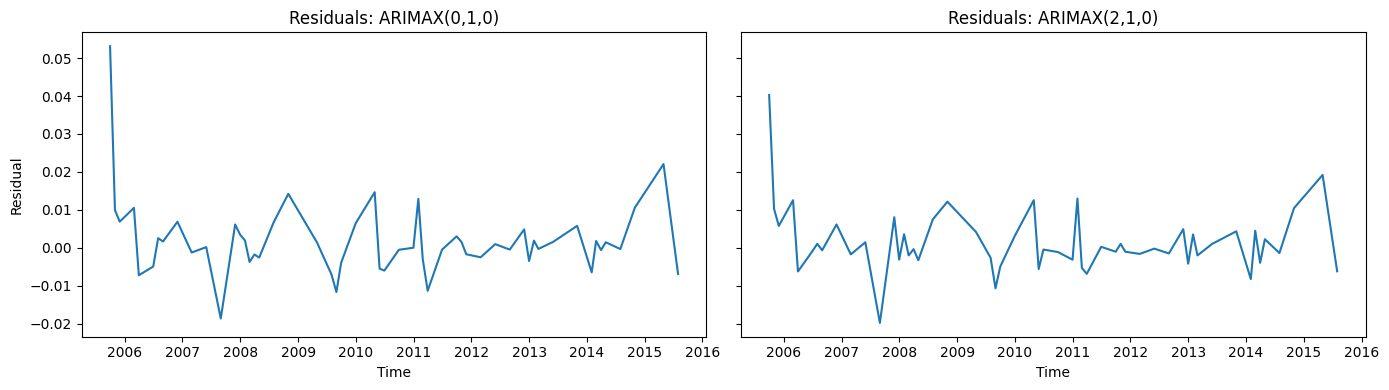

In [ ]:
# Extract residuals
resid_010 = pd.Series(results_arimax_010.resid).dropna()
resid_210 = pd.Series(results_arimax_210.resid).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# ARIMAX(0,1,0)
axes[0].plot(resid_010.index, resid_010.values)
axes[0].set_title("Residuals: ARIMAX(0,1,0)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Residual")

# ARIMAX(2,1,0)
axes[1].plot(resid_210.index, resid_210.values)
axes[1].set_title("Residuals: ARIMAX(2,1,0)")
axes[1].set_xlabel("Time")

plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


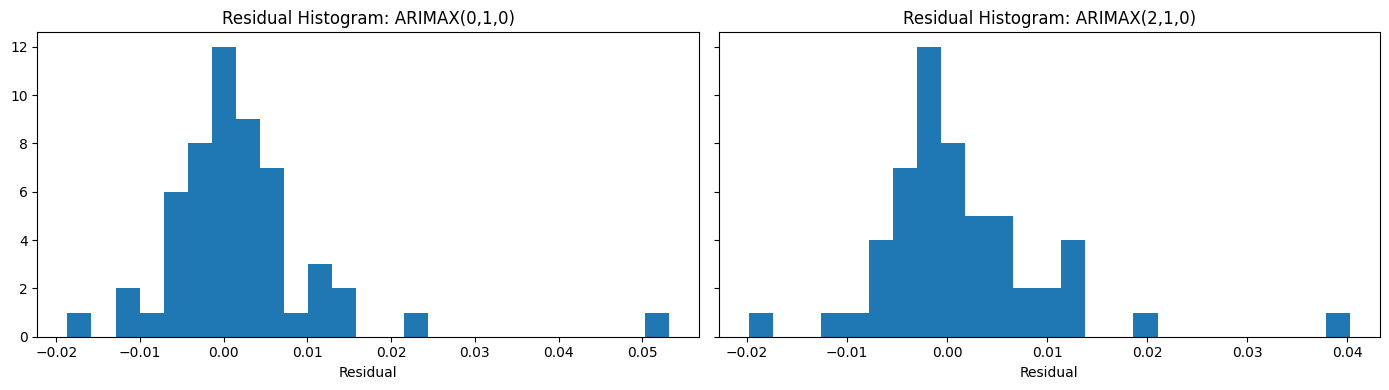

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# ARIMAX(0,1,0)
axes[0].hist(resid_010.values, bins=25)
axes[0].set_title("Residual Histogram: ARIMAX(0,1,0)")
axes[0].set_xlabel("Residual")

# ARIMAX(2,1,0)
axes[1].hist(resid_210.values, bins=25)
axes[1].set_title("Residual Histogram: ARIMAX(2,1,0)")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


In [33]:
"""
Models from previously (for reference)
residuals_arima 
resid_010
resid_210
"""

'\nModels from previously (for reference)\nresiduals_arima \nresid_010\nresid_210\n'

In [34]:
# Generate forecasts over test sample
h = len(y_test)

# ARIMAX forecasts (use fitted RESULTS objects, not residual series)
fc_arimax_010 = results_arimax_010.get_forecast(steps=h, exog=X_test_f).predicted_mean
fc_arimax_210 = results_arimax_210.get_forecast(steps=h, exog=X_test_f).predicted_mean

# ARIMA baseline forecast 
fc_arima = results_arima.get_forecast(steps=h).predicted_mean

# Align indices for plotting
fc_arimax_010.index = y_test.index
fc_arimax_210.index = y_test.index
fc_arima.index      = y_test.index


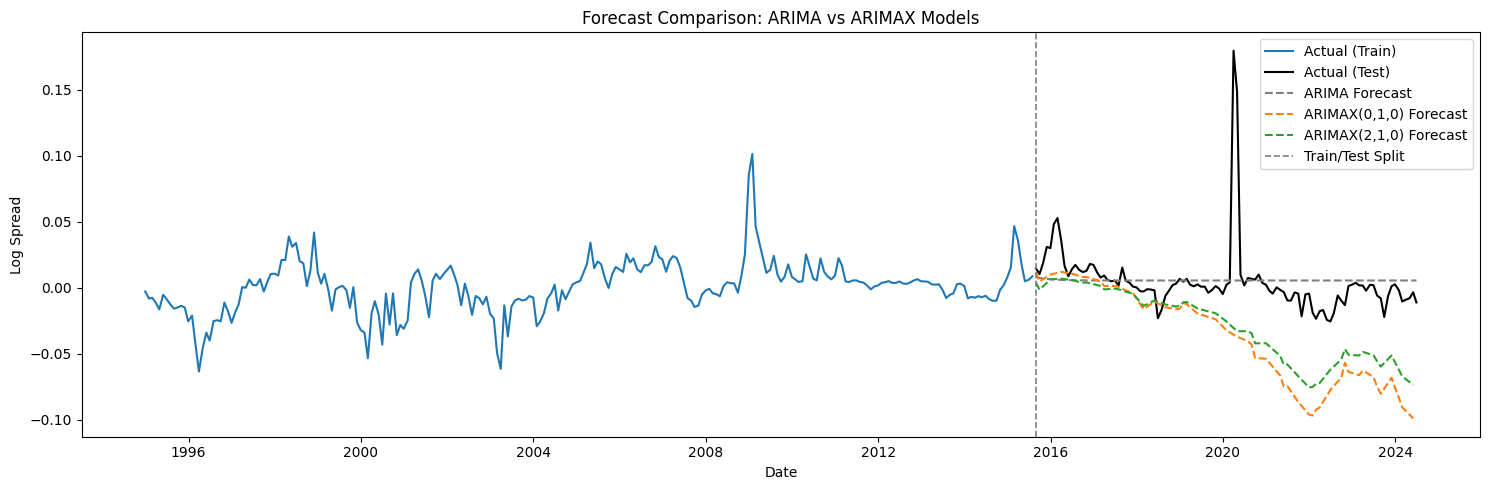

In [ ]:
plt.figure(figsize=(15, 5))

# Actual series (from df split)
plt.plot(df_train.index, df_train["ln_spread"], label="Actual (Train)", color="tab:blue")
plt.plot(df_test.index,  df_test["ln_spread"],  label="Actual (Test)",  color="black")

# --- ARIMA baseline forecast (reuse from forecast_df) ---
plt.plot(
    forecast_df.index,
    forecast_df["forecast"],
    label="ARIMA Forecast",
    linestyle="--",
    color="tab:gray"
)

plt.plot(
    fc_arimax_010.index,
    fc_arimax_010.values,
    label="ARIMAX(0,1,0) Forecast",
    linestyle="--",
    color="tab:orange"
)

plt.plot(
    fc_arimax_210.index,
    fc_arimax_210.values,
    label="ARIMAX(2,1,0) Forecast",
    linestyle="--",
    color="tab:green"
)

# Train/Test split line
plt.axvline(x=df_test.index[0], linestyle="--", linewidth=1.2, color="gray", label="Train/Test Split")

plt.title("Forecast Comparison: ARIMA vs ARIMAX Models")
plt.xlabel("Date")
plt.ylabel("Log Spread")
plt.legend()
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


In [36]:
# Common evaluation window = ARIMAX test horizon
common_idx = fc_arimax_010.index 

# Actuals on common window
y_train_full = df_train["ln_spread"]
y_test_full  = df_test["ln_spread"]

y_test = y_test_full.reindex(common_idx).dropna()

# Training sample up to just before test starts (for benchmarks)
train_cutoff = common_idx[0]
y_train = y_train_full.loc[y_train_full.index < train_cutoff]

# Benchmarks on test set
bench_last = pd.concat([y_train.iloc[-1:], y_test.iloc[:-1]])
bench_last.index = y_test.index
bench_last.name = "Benchmark_LastObs"

bench_mean = pd.Series(float(y_train.mean()), index=y_test.index, name="Benchmark_TrainMean")

y_pred_arimax_010 = fc_arimax_010.reindex(common_idx).rename("ARIMAX(0,1,0)")
y_pred_arimax_210 = fc_arimax_210.reindex(common_idx).rename("ARIMAX(2,1,0)")

# Metric functions 
# def mae(y_true, y_hat):
#     return float(np.mean(np.abs(y_true - y_hat)))

# def rmse(y_true, y_hat):
#     return float(np.sqrt(np.mean((y_true - y_hat) ** 2)))

# def hitrate(y_true, y_hat, y_prev):
#     actual_dir = np.sign(y_true - y_prev)
#     pred_dir   = np.sign(y_hat - y_prev)
#     return float(np.mean(actual_dir.values == pred_dir.values))

# def oos_r2(y_true, y_hat, y_bench):
#     sse_model = float(np.sum((y_true - y_hat) ** 2))
#     sse_bench = float(np.sum((y_true - y_bench) ** 2))
#     return np.nan if sse_bench == 0 else 1.0 - (sse_model / sse_bench)

# Assemble metrics table (benchmarks + both ARIMAX)
preds = {
    bench_last.name: bench_last,
    bench_mean.name: bench_mean,
    y_pred_arimax_010.name: y_pred_arimax_010,
    y_pred_arimax_210.name: y_pred_arimax_210,
}

rows = []
for name, y_hat in preds.items():
    # Align and drop any NaNs
    ok = pd.concat([y_test, y_hat, bench_last, bench_mean], axis=1).dropna()
    yt = ok.iloc[:, 0]
    yh = ok.iloc[:, 1]
    bl = ok.iloc[:, 2]
    bm = ok.iloc[:, 3]

    rows.append({
        "Model": name,
        "Hitrate": hitrate(yt, yh, bl),
        "MAE": mae(yt, yh),
        "RMSE": rmse(yt, yh),
        "OOS_R2_vs_LastObs": 0.0 if name == bench_last.name else oos_r2(yt, yh, bl),
        "OOS_R2_vs_TrainMean": 0.0 if name == bench_mean.name else oos_r2(yt, yh, bm),
    })

metrics_arimax = pd.DataFrame(rows).set_index("Model")
display(metrics_arimax)


,Hitrate,MAE,RMSE,OOS_R2_vs_LastObs,OOS_R2_vs_TrainMean
Model,,,,,
Benchmark_LastObs,0.000000,0.011429,0.029978,0.000000,-0.553921
Benchmark_TrainMean,0.571429,0.011377,0.024048,0.356467,0.000000
"ARIMAX(0,1,0)",0.571429,0.042896,0.055784,-2.462704,-4.380769
"ARIMAX(2,1,0)",0.551020,0.035367,0.045817,-1.335892,-2.629792


Although both ARIMAX specifications produce negative out-of-sample $R^2$ values relative to the benchmark models, indicating that neither consistently outperforms naïve alternatives, there is clear evidence that ARIMAX(2,1,0) delivers superior forecast performance compared to ARIMAX(0,1,0). In particular, ARIMAX(2,1,0) achieves lower MAE and RMSE and a higher directional hit rate, suggesting improved accuracy and more informative dynamics in the forecasted log spread. Consequently, despite remaining inferior to simple benchmarks in absolute terms, ARIMAX(2,1,0) is selected for subsequent analysis as it provides a meaningful improvement over the more restrictive ARIMAX(0,1,0) specification.

# Rolling Window Forecasts

To assess forecast stability, a 24-month rolling window one-step-ahead forecasting exercise was conducted for both ARIMA and ARIMAX models. This approach allows model parameters to adapt over time and provides a realistic evaluation of performance under evolving market conditions. The results indicate that the ARIMAX(2,1,0) model delivers consistently lower forecast errors and improved directional accuracy relative to the ARIMA benchmark, reinforcing its suitability for practical forecasting.

In [37]:
# Rolling ARIMA(1,1,1) forecasts
WINDOW = 24
order_arima = (1,1,1)

y_all = df["ln_spread"].dropna()
test_idx = df_test.index  # should start ~2015-12

rolling_fc_arima = []

for t in test_idx:
    # window ends at t-1
    y_win = y_all.loc[:t].iloc[-(WINDOW+1):-1]  # last 24 obs before t
    if len(y_win) < WINDOW:
        rolling_fc_arima.append(np.nan)
        continue

    res = ARIMA(y_win, order=order_arima, trend="n").fit()
    rolling_fc_arima.append(res.forecast(1).iloc[0])

rolling_fc_arima = pd.Series(rolling_fc_arima, index=test_idx, name="ARIMA_rolling")



rolling_fc_arimax = []
rolling_idx = []

# Combine train + test exog
X_all = pd.concat([X_train_f, X_test_f]).reindex(y_all.index)

for t in range(WINDOW, len(y_all) - 1):
    y_window = y_all.iloc[t-WINDOW:t]
    X_window = X_all.iloc[t-WINDOW:t]
    X_next   = X_all.iloc[t:t+1]

    try:
        res = ARIMA(
            y_window,
            order=(2,1,0),
            exog=X_window,
            trend="n"
        ).fit(method="statespace")

        fc = res.forecast(steps=1, exog=X_next).iloc[0]
    except:
        fc = np.nan

    rolling_fc_arimax.append(fc)
    rolling_idx.append(y_all.index[t])

rolling_fc_arimax = pd.Series(rolling_fc_arimax, index=rolling_idx, name="ARIMAX(2,1,0)_Rolling")



In [38]:
# Rolling ARIMAX(2,1,0) forecasts

ORDER_ARIMAX = (2, 1, 0)

# 1) Build a joint dataset (only dates where y and X BOTH exist)
y_all = df["ln_spread"].dropna()

# X_all should already be your combined exog panel aligned to dates
# If you only have X_train_f and X_test_f, combine them:
X_all = pd.concat([X_train_f, X_test_f]).sort_index()

joint = pd.concat([y_all.rename("y"), X_all], axis=1).dropna()
y_joint = joint["y"]
X_joint = joint.drop(columns=["y"])

print("Joint start/end:", y_joint.index.min(), "->", y_joint.index.max(), "n=", len(y_joint))

# 2) Rolling one-step-ahead forecasts across the joint sample
rolling_fc_arimax = []

# We forecast at index position i using window [i-WINDOW, i-1]
for i in range(WINDOW, len(y_joint)):
    y_win = y_joint.iloc[i-WINDOW:i]
    X_win = X_joint.iloc[i-WINDOW:i]
    X_t   = X_joint.iloc[i:i+1]         # exog at forecast date
    t     = y_joint.index[i]

    try:
        res = ARIMA(
            y_win,
            order=ORDER_ARIMAX,
            exog=X_win,
            trend="n"
        ).fit(method="statespace")

        yhat = res.forecast(steps=1, exog=X_t).iloc[0]
    except Exception:
        yhat = np.nan

    rolling_fc_arimax.append((t, yhat))

rolling_fc_arimax = pd.Series(
    data=[v for _, v in rolling_fc_arimax],
    index=[t for t, _ in rolling_fc_arimax],
    name="ARIMAX(2,1,0)_Rolling"
).dropna()

Joint start/end: 2005-09-30 00:00:00 -> 2024-05-31 00:00:00 n= 103


In [39]:
# Align actual and evaluate performance
# Actuals corresponding to rolling forecasts
y_true_roll = y_all.reindex(rolling_idx)

# Drop missing forecasts
eval_df = pd.concat(
    [y_true_roll, rolling_fc_arima, rolling_fc_arimax],
    axis=1
).dropna()

y_true = eval_df.iloc[:, 0]
fc_arima = eval_df.iloc[:, 1]
fc_arimax = eval_df.iloc[:, 2]

In [40]:
# Metrics
rolling_metrics = pd.DataFrame({
    "MAE": [
        mae(y_true, fc_arima),
        mae(y_true, fc_arimax)
    ],
    "RMSE": [
        rmse(y_true, fc_arima),
        rmse(y_true, fc_arimax)
    ],
    "Hitrate": [
        hitrate(y_true, fc_arima, y_true.shift(1)),
        hitrate(y_true, fc_arimax, y_true.shift(1))
    ]
}, index=["ARIMA (Rolling)", "ARIMAX(2,1,0) (Rolling)"])

display(rolling_metrics)


,MAE,RMSE,Hitrate
ARIMA (Rolling),0.006236,0.011009,0.632653
"ARIMAX(2,1,0) (Rolling)",0.015300,0.028437,0.510204


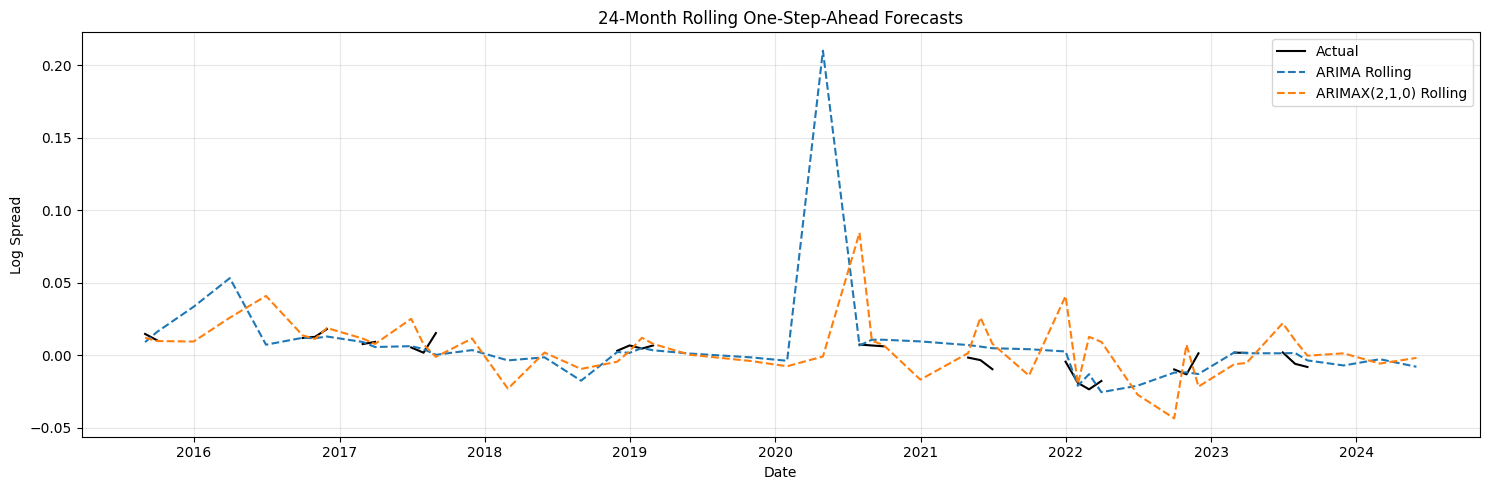

In [53]:
# Rolling forecast plot
plt.figure(figsize=(15, 5))

plt.plot(y_true.index, y_true.values, label="Actual", color="black")
plt.plot(fc_arima.index, fc_arima.values, label="ARIMA Rolling", linestyle="--")
plt.plot(fc_arimax.index, fc_arimax.values, label="ARIMAX(2,1,0) Rolling", linestyle="--")

plt.title("24-Month Rolling One-Step-Ahead Forecasts")
plt.xlabel("Date")
plt.ylabel("Log Spread")
plt.legend()
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


# Performance and Trading Strategy

## Cumulative Economic Performance

$$
\Pi_T=\sum{t=1}^T\pi_t
$$

In [45]:
# Ensure all series have consistent datetime indices
common_idx = (
    y_joint.index
    .intersection(rolling_fc_arima.dropna().index)
    .intersection(rolling_fc_arimax.dropna().index)
).sort_values()

# 2. Align all series to the common index
y_true_aligned = y_joint.loc[common_idx]
y_prev_aligned = y_joint.shift(1).loc[common_idx] # Previous actual for direction
fc_arima_aligned  = rolling_fc_arima.loc[common_idx]
fc_arimax_aligned = rolling_fc_arimax.loc[common_idx]

In [ ]:
# Calculate Strategy Returns (Trading Rules)
"""Generate Trading Signals
A signal of 1 means 'Long Spread' (CL2-CL1), -1 means 'Short Spread'
Logic: If the model forecasts a spread higher than the last actual spread, go long.
"""
signal_arima  = np.sign(fc_arima_aligned - y_prev_aligned)
signal_arimax = np.sign(fc_arimax_aligned - y_prev_aligned)

# Periodic returns = signal * actual change in spread
actual_changes = y_true_aligned - y_prev_aligned
strat_ret_arima  = signal_arima * actual_changes
strat_ret_arimax = signal_arimax * actual_changes

In [47]:
# Calculate Cumulative Performance
cum_perf_arima  = strat_ret_arima.cumsum()
cum_perf_arimax = strat_ret_arimax.cumsum()
cum_perf_bench  = actual_changes.cumsum() # Naive 'Buy and Hold' the spread

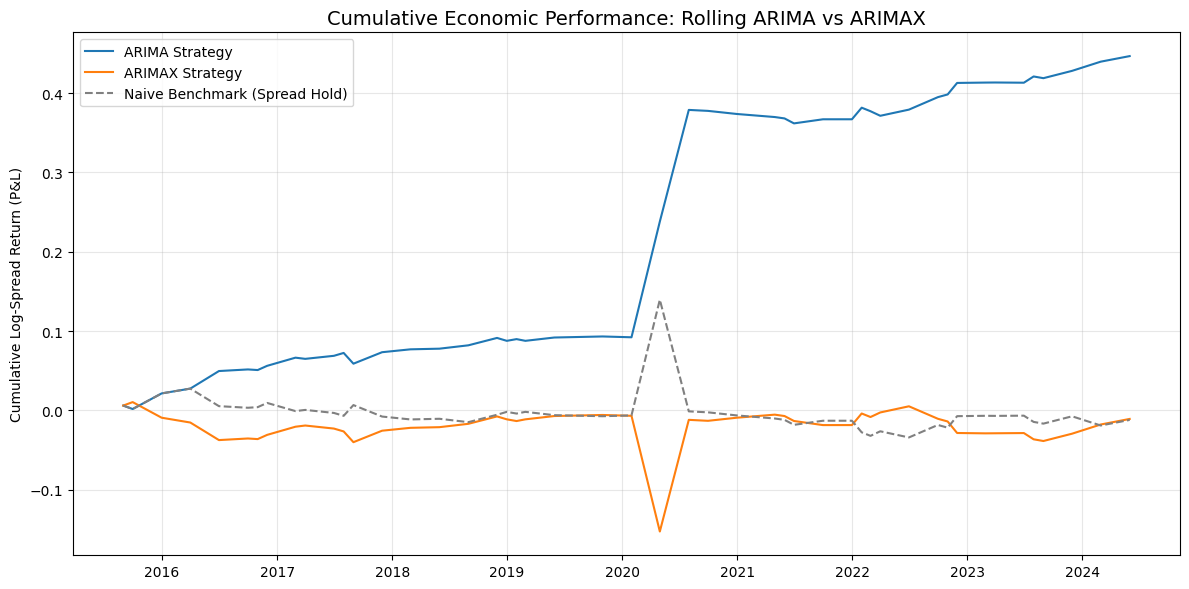

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(cum_perf_arima, label="ARIMA Strategy", color='tab:blue')
plt.plot(cum_perf_arimax, label="ARIMAX Strategy", color='tab:orange')
plt.plot(cum_perf_bench, label="Naive Benchmark (Spread Hold)", color='gray', linestyle='--')

plt.title("Cumulative Economic Performance: Rolling ARIMA vs ARIMAX", fontsize=14)
plt.ylabel("Cumulative Log-Spread Return (P&L)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Strategy Performance

In [49]:
# Calculate Sharpe Ratio
def sharpe(pnl: pd.Series) -> float:
    pnl = pnl.dropna()
    sd = pnl.std(ddof=1)
    if sd == 0 or np.isnan(sd):
        return np.nan
    return float(pnl.mean() / sd * np.sqrt(12))  # monthly -> annualised

# Calculate Maximum Drawdown
def max_drawdown(eq: pd.Series) -> float:
    eq = eq.dropna()
    peak = eq.cummax()
    dd = eq - peak
    return float(dd.min())

In [50]:
"""
Strategy constructor
forecast is a level forecast of y_t (ln_spread)
we trade sign(forecast - y_{t-1})
"""

def strategy_from_forecast(
    name: str,
    forecast: pd.Series,
    y_true: pd.Series,
    threshold: float = 0.0,     # set >0 to avoid trading on tiny signals
    cost_bps: float = 0.0       # transaction cost per position change (bps)
):
    # Align
    idx = y_true.index.intersection(forecast.index)
    y = y_true.reindex(idx)
    fc = forecast.reindex(idx)

    # Previous actual and realised change
    y_prev = y.shift(1)
    dy = y - y_prev

    # Signal based on forecasted change
    signal = fc - y_prev
    pos = np.sign(signal)

    # Optional threshold (dead zone)
    if threshold > 0:
        pos = pos.where(signal.abs() > threshold, 0.0)

    # Transaction costs: cost applies when position changes
    # Convert bps to decimal "return" units: bps * 1e-4
    turnover = pos.diff().abs().fillna(0.0)
    costs = turnover * (cost_bps * 1e-4)

    pnl = (pos * dy) - costs
    eq = pnl.cumsum()

    out = pd.DataFrame({
        "y": y,
        "forecast": fc,
        "pos": pos,
        "dy": dy,
        "turnover": turnover,
        "costs": costs,
        "pnl": pnl,
        "equity": eq
    }).dropna()

    return out["equity"], out["pnl"], out["pos"]

In [51]:
"""Build common evaluation set
(keep dates where y_joint exists and 
at least ARIMAX forecast exists)
"""

common_idx = y_joint.index.intersection(rolling_fc_arimax.index)
y_eval = y_joint.reindex(common_idx).dropna()

# Benchmark TrainMean: constant forecast of level y_t
bench_mean_fc = pd.Series(float(y_eval.mean()), index=y_eval.index, name="Benchmark TrainMean")

# Define strategies to evaluate
STRAT_THRESHOLD = 0.0   # change to e.g. 0.001 if you want a no-trade zone
COST_BPS = 0.0          # change to e.g. 1 or 5 if you want to include costs

strategy_dict = {
    "ARIMA Rolling": rolling_fc_arima.reindex(y_eval.index),
    "ARIMAX(2,1,0) Rolling": rolling_fc_arimax.reindex(y_eval.index),

    # Benchmark
    "Benchmark TrainMean": bench_mean_fc
}

In [52]:
# Strategy performance table
econ_rows = []

for name, fc in strategy_dict.items():
    eq, pnl, pos = strategy_from_forecast(
        name=name,
        forecast=fc,
        y_true=y_eval,
        threshold=STRAT_THRESHOLD,
        cost_bps=COST_BPS
    )

    econ_rows.append({
        "Strategy": name,
        "Total_PnL": float(pnl.sum()),
        "Avg_PnL": float(pnl.mean()),
        "Sharpe_Ann": sharpe(pnl),
        "Max_Drawdown": max_drawdown(eq),
        "Turnover": float(pos.diff().abs().fillna(0).sum())
    })

econ_df = (
    pd.DataFrame(econ_rows)
      .set_index("Strategy")
      .sort_values("Total_PnL", ascending=False)
)

display(econ_df)

,Total_PnL,Avg_PnL,Sharpe_Ann,Max_Drawdown,Turnover
Strategy,,,,,
ARIMA Rolling,0.446680,0.009116,1.094421,-0.016995,40.0
Benchmark TrainMean,0.371585,0.004764,0.691818,-0.027738,26.0
"ARIMAX(2,1,0) Rolling",0.041071,0.000527,0.074985,-0.170758,76.0


The rolling ARIMA strategy achieves the strongest economic performance among the models considered, delivering both higher total and average profit-and-loss relative to the mean benchmark and the ARIMAX specification. This indicates that the univariate ARIMA model is able to effectively exploit short-run persistence in the log spread, translating statistical predictability into economically meaningful trading gains. In contrast, the mean benchmark performs more weakly, reflecting its inability to adapt to changing market conditions.

Despite incorporating additional macroeconomic and financial information, the ARIMAX-based strategy exhibits substantially higher turnover than the univariate ARIMA benchmark, indicating more frequent position changes driven by fluctuations in the exogenous variables. However, this increased trading intensity does not translate into superior economic outcomes. The ARIMAX strategy generates lower cumulative returns and a markedly weaker Sharpe ratio, suggesting that the additional variables introduce noise rather than stable predictive signals for trading the spread.

Overall, these results highlight a trade-off between model complexity and economic performance. While ARIMAX provides a richer information set, it appears to overtrade on relatively weak signals, leading to inferior risk-adjusted performance. By contrast, the more parsimonious ARIMA model delivers smoother and more profitable trading outcomes, underscoring the importance of simplicity and stability when translating forecasts into economic decisions.